In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
train_df=pd.read_csv('D:\\DS Part(2)\\F1_pitstop\\playground-series-s6e5\\train.csv')
test_df=pd.read_csv('D:\\DS Part(2)\\F1_pitstop\\playground-series-s6e5\\test.csv')
test_id=test_df['id']
train_df=train_df.drop('id',axis=1)
test_df=test_df.drop('id',axis=1)


In [13]:
print(train_df.columns)
print(test_df.columns)

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')
Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change'],
      dtype='object')


In [15]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [ ]:
num_columns=train_df.select_dtypes(exclude='object').columns
cat_columns=train_df.select_dtypes(include='object').columns


Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object


In [46]:

print('Features                 Data type')
print('----------------------------------')
print(train_df[num_columns].dtypes)



Features                 Data type
----------------------------------
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object


In [49]:

print('Features   Data type')
print('----------------------------------')
print(train_df[cat_columns].dtypes)



Features   Data type
----------------------------------
Driver      object
Compound    object
Race        object
dtype: object


#cheack data has null values or duplicates


In [54]:
print('Features                Null values')
print('----------------------------------')
print(train_df[num_columns].isnull().sum())

Features                Null values
----------------------------------
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64


In [55]:
print('Features   Data type')
print('----------------------------------')
print(train_df[cat_columns].isnull().sum())

Features   Data type
----------------------------------
Driver      0
Compound    0
Race        0
dtype: int64


In [71]:

print(f"Duplicated rows sum: {train_df.duplicated().sum()}")



Duplicated rows sum: 0


In [69]:
train_df.loc[train_df.duplicated(subset=num_columns, keep=False), cat_columns]

,Driver,Compound,Race
3216,D113,MEDIUM,Abu Dhabi Grand Prix
10265,D346,MEDIUM,Mexico City Grand Prix
12540,GRO,MEDIUM,Hungarian Grand Prix
15774,D203,MEDIUM,Japanese Grand Prix
19304,D286,MEDIUM,Pre-Season Testing
20363,DIR,MEDIUM,British Grand Prix
20726,D129,MEDIUM,British Grand Prix
33724,D263,MEDIUM,Pre-Season Testing
33789,D075,MEDIUM,British Grand Prix
53378,D393,MEDIUM,Pre-Season Testing


In [87]:
train_df['PitNextLap']=train_df['PitNextLap'].astype(int)
values=train_df['PitNextLap'].value_counts()
print(values)

PitNextLap
0    351759
1     87381
Name: count, dtype: int64


##cc

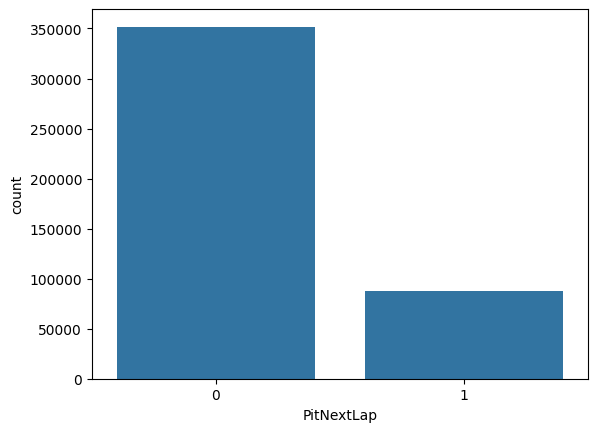

In [96]:
plt.subplot(1,1,1)
sns.barplot(values)
plt.show()




In [105]:
train_df

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,D755,MEDIUM,Miami Grand Prix,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0,0
439136,D731,MEDIUM,Miami Grand Prix,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0,0
439137,D716,MEDIUM,Miami Grand Prix,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0,0
439138,D665,HARD,Abu Dhabi Grand Prix,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0,0


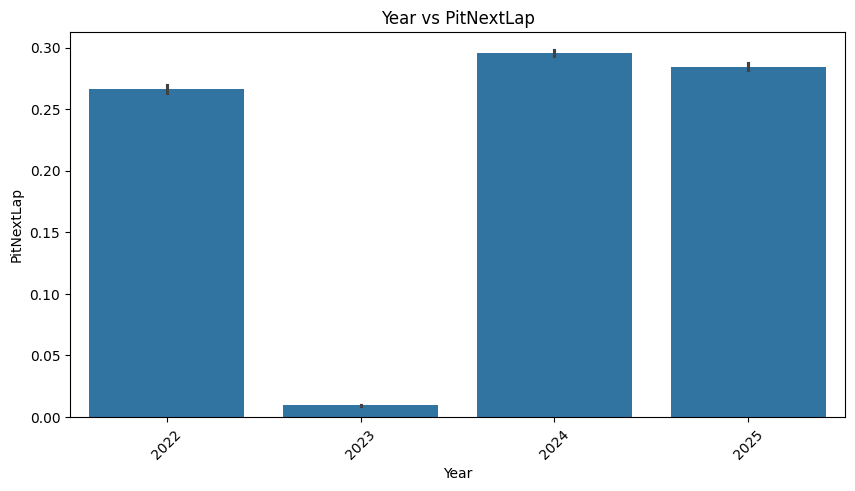

In [104]:

df_sorted = train_df.sort_values(by='Year')

plt.figure(figsize=(10,5))
sns.barplot(x='Year', y='PitNextLap', data=df_sorted)

plt.xticks(rotation=45)
plt.title('Year vs PitNextLap')
plt.show()